In [1]:
# Mount Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install & Verify GPU

!pip install ultralytics -q
!pip install roboflow -q

import torch
import os
import shutil
import yaml
import json
import random
import time
import matplotlib.pyplot as plt
import pandas as pd
from ultralytics import YOLO

print(" Libraries installed!")
print(" GPU available:", torch.cuda.is_available())
print(" GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 112.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
 Libraries installed!
 GPU available: True
 GPU name: Tesla T4


In [3]:
#  Download Dataset

from roboflow import Roboflow

base = '/content/drive/MyDrive/advanced_banana_quality_project'

rf = Roboflow(api_key="AWdQF1S7BbXRcYXNFcRM")
project = rf.workspace("fruit-ripening").project("banana-ripening-process")
version = project.version(2)
dataset = version.download("yolov8", location="/content/banana_detection")

print(" Dataset downloaded!")

# Verify all folders
det_base = "/content/banana_detection"
print("\n Folder structure:")
for split in ['train', 'valid', 'test']:
    for sub in ['images', 'labels']:
        path = f"{det_base}/{split}/{sub}"
        if os.path.exists(path):
            print(f"    {split}/{sub}: {len(os.listdir(path))} files")
        else:
            print(f"    {split}/{sub}: MISSING")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/banana_detection in yolov8:: 100%|██████████| 36160/36160 [00:09<00:00, 3827.85it/s] 


 Dataset downloaded!

 Folder structure:
    train/images: 15792 files
    train/labels: 15792 files
    valid/images: 1525 files
    valid/labels: 1525 files
    test/images: 757 files
    test/labels: 757 files


In [4]:
# Fix data.yaml

yaml_path = "/content/banana_detection/data.yaml"

yaml_content = {
    'train': '/content/banana_detection/train/images',
    'val': '/content/banana_detection/valid/images',
    'test': '/content/banana_detection/test/images',
    'nc': 6,
    'names': ['freshripe', 'freshunripe', 'overripe', 'ripe', 'rotten', 'unripe']
}

with open(yaml_path, 'w') as f:
    yaml.dump(yaml_content, f)

print(" data.yaml fixed!")
print(f"   Classes : {yaml_content['names']}")
print(f"   Train   : {yaml_content['train']}")
print(f"   Val     : {yaml_content['val']}")
print(f"   Test    : {yaml_content['test']}")

 data.yaml fixed!
   Classes : ['freshripe', 'freshunripe', 'overripe', 'ripe', 'rotten', 'unripe']
   Train   : /content/banana_detection/train/images
   Val     : /content/banana_detection/valid/images
   Test    : /content/banana_detection/test/images


In [5]:
# Train YOLOv8 (Save Locally First!)

# Train to LOCAL storage first (prevents losing weights on disconnect)
yolo_model = YOLO('yolov8n.pt')

print(" Starting YOLOv8 training...")
print("   Saving to LOCAL /content first for safety!")

results = yolo_model.train(
    data=yaml_path,
    epochs=36,
    imgsz=416,
    batch=16,
    patience=10,
    project='/content/yolo_runs',  # LOCAL - not Drive!
    name='yolo_detection_run',
    exist_ok=True
)

print("\n Training complete!")

 Starting YOLOv8 training...
   Saving to LOCAL /content first for safety!
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/banana_detection/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=36, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_detection_run, nb

In [6]:
# Save Weights to Drive Immediately

print(" Saving weights to Google Drive...")

local_run = '/content/yolo_runs/yolo_detection_run'
best_src  = f'{local_run}/weights/best.pt'
last_src  = f'{local_run}/weights/last.pt'

# Save best and last weights
shutil.copy(best_src, f'{base}/models/yolo_detect_best.pt')
shutil.copy(last_src, f'{base}/models/yolo_detect_last.pt')

# Copy full run folder (has plots, results.csv etc.)
shutil.copytree(
    local_run,
    f'{base}/models/yolo_detection_run',
    dirs_exist_ok=True
)

print(" Weights saved to Drive!")
print(f"   best.pt size : {os.path.getsize(f'{base}/models/yolo_detect_best.pt')/1024/1024:.1f} MB")
print(f"   last.pt size : {os.path.getsize(f'{base}/models/yolo_detect_last.pt')/1024/1024:.1f} MB")

 Saving weights to Google Drive...
 Weights saved to Drive!
   best.pt size : 5.9 MB
   last.pt size : 5.9 MB


In [7]:
# Evaluate on Test Set (mAP)

# Load best model
best_yolo = YOLO(f'{base}/models/yolo_detect_best.pt')

print(" Evaluating on test set...")
metrics = best_yolo.val(
    data=yaml_path,
    split='test'
)

print("\n YOLO Detection Metrics:")
print(f"   mAP50    : {metrics.box.map50:.4f}")
print(f"   mAP50-95 : {metrics.box.map:.4f}")
print(f"   Precision: {metrics.box.mp:.4f}")
print(f"   Recall   : {metrics.box.mr:.4f}")

# Save results
yolo_results = {
    'model': 'YOLOv8n Detection',
    'mAP50': round(float(metrics.box.map50), 4),
    'mAP50_95': round(float(metrics.box.map), 4),
    'precision': round(float(metrics.box.mp), 4),
    'recall': round(float(metrics.box.mr), 4),
    'epochs_trained': 50,
    'imgsz': 416,
    'classes': yaml_content['names']
}

with open(f'{base}/reports/yolo_detection_results.json', 'w') as f:
    json.dump(yolo_results, f, indent=4)

print("\n YOLO results saved to reports folder!")

 Evaluating on test set...
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 359.0±132.0 MB/s, size: 15.9 KB)
val: Scanning /content/banana_detection/test/labels... 757 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 757/757 1.6Kit/s 0.5s
val: New cache created: /content/banana_detection/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 48/48 7.0it/s 6.9s
                   all        757       1519      0.869      0.896      0.949      0.701
             freshripe        130        156      0.871      0.885      0.953      0.772
           freshunripe         99        212      0.841      0.946      0.955       0.74
              overripe        145        178      0.919      0.955      0.982      0.811
                  ripe        205        35

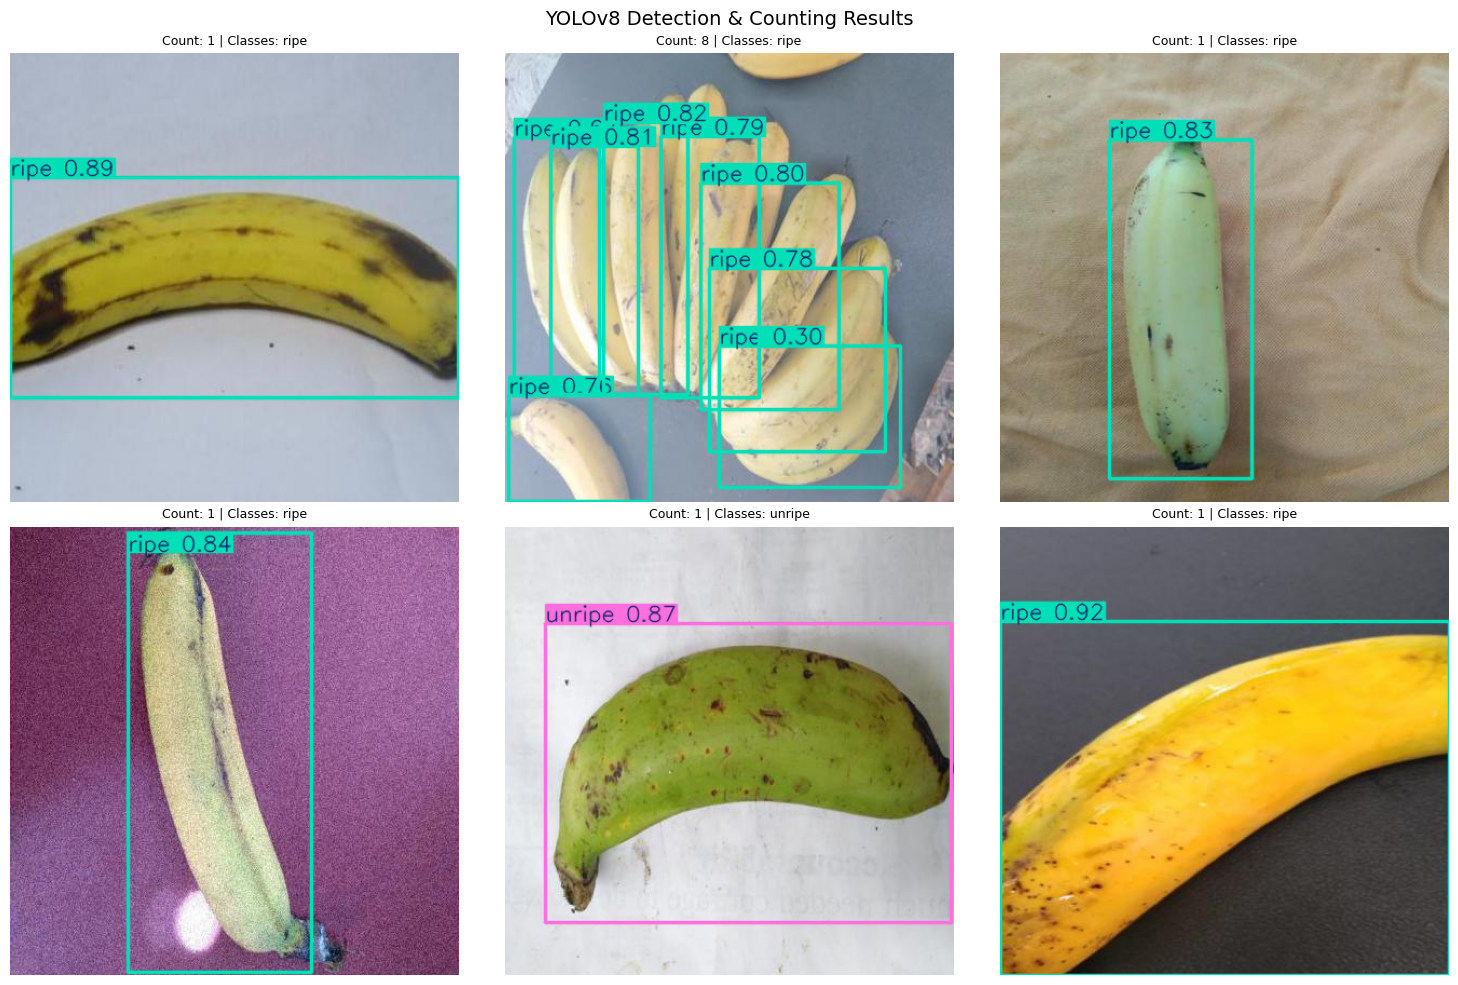

 Detection samples saved!


In [8]:
# Test Detection + Counting on Sample Images

import matplotlib.pyplot as plt

test_img_dir = "/content/banana_detection/test/images"
sample_images = random.sample(os.listdir(test_img_dir), 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

counting_results = []

for i, img_name in enumerate(sample_images):
    img_path = f"{test_img_dir}/{img_name}"

    # Predict
    pred = best_yolo.predict(img_path, conf=0.25, verbose=False)
    result = pred[0]

    # Count bananas
    banana_count = len(result.boxes)

    # Class names detected
    if banana_count > 0:
        detected_classes = [
            yaml_content['names'][int(c)]
            for c in result.boxes.cls.tolist()
        ]
        class_summary = ', '.join(set(detected_classes))
    else:
        class_summary = 'none'

    # Plot
    plotted = result.plot()
    plotted_rgb = plotted[:, :, ::-1]

    axes[i].imshow(plotted_rgb)
    axes[i].set_title(
        f'Count: {banana_count} | Classes: {class_summary}',
        fontsize=9
    )
    axes[i].axis('off')

    counting_results.append({
        'image': img_name,
        'predicted_count': banana_count,
        'detected_classes': class_summary
    })

plt.suptitle('YOLOv8 Detection & Counting Results', fontsize=14)
plt.tight_layout()
plt.savefig(f'{base}/screenshots/yolo_detection_samples.png')
plt.show()
print(" Detection samples saved!")

In [9]:
# Counting Accuracy Table

count_df = pd.DataFrame(counting_results)
count_df.to_csv(f'{base}/reports/counting_accuracy.csv', index=False)

print(" Counting Results Table:")
print(count_df.to_string(index=False))
print("\n Saved to reports/counting_accuracy.csv!")


 Counting Results Table:
                                                                                                        image  predicted_count detected_classes
         musa-acuminata-ripe-92b1fe44-1d0a-11ec-8de7-d8c4975e38aa_jpg.rf.e195d01fd029600fab0bf78bc73745bb.jpg                1             ripe
       musa-acuminata-banana-b6f8e0e7-394a-11ec-904c-d8c4975e38aa_jpg.rf.41cfa3ddbe099c2a8d168ef0d77a0247.jpg                8             ripe
       musa-acuminata-banana-cd3c2465-4037-11ec-94dd-94b86d66fd1d_jpg.rf.4d3311bd47bdad16581f64a184fc34b2.jpg                1             ripe
       musa-acuminata-banana-e4d0daa9-394a-11ec-a571-d8c4975e38aa_jpg.rf.4bc8bdaebe664dcdfe9c9543f1981db8.jpg                1             ripe
musa-acuminata-unripe-5e922cce-2653-11ec-8680-d8c4975e38aa---Copy_jpg.rf.24bcde2b28b47dd48e53f30c8d983b31.jpg                1           unripe
       musa-acuminata-banana-ca353007-394a-11ec-9f15-d8c4975e38aa_jpg.rf.c3a15c32301e1e3831844f8d01f12260.jpg  

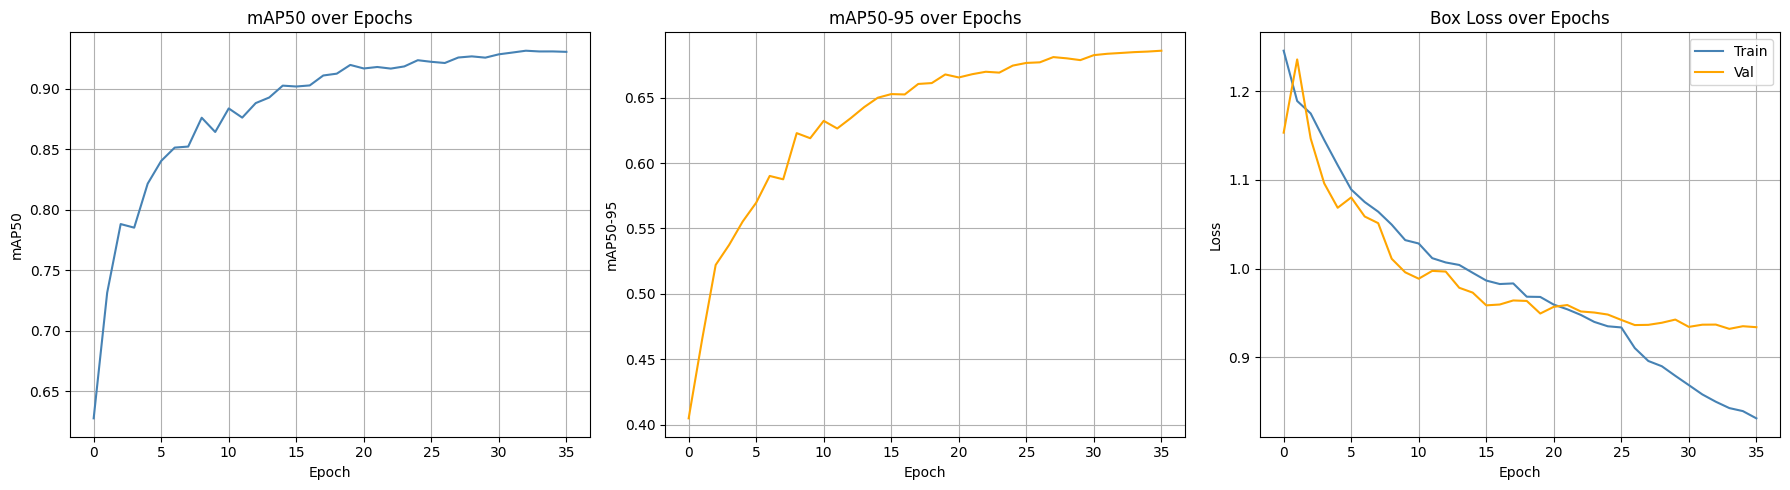

 Training curves saved!


In [10]:
#  Training Curves from Results CSV

results_csv = f'{base}/models/yolo_detection_run/results.csv'

if os.path.exists(results_csv):
    df_results = pd.read_csv(results_csv)
    df_results.columns = df_results.columns.str.strip()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # mAP50
    axes[0].plot(df_results['metrics/mAP50(B)'], color='steelblue')
    axes[0].set_title('mAP50 over Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('mAP50')
    axes[0].grid(True)

    # mAP50-95
    axes[1].plot(df_results['metrics/mAP50-95(B)'], color='orange')
    axes[1].set_title('mAP50-95 over Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('mAP50-95')
    axes[1].grid(True)

    # Box Loss
    axes[2].plot(df_results['train/box_loss'], label='Train', color='steelblue')
    axes[2].plot(df_results['val/box_loss'], label='Val', color='orange')
    axes[2].set_title('Box Loss over Epochs')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Loss')
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.savefig(f'{base}/screenshots/yolo_training_curves.png')
    plt.show()
    print(" Training curves saved!")
else:
    print(" results.csv not found!")

In [11]:
#  Final Summary

print("=" * 50)
print(" NOTEBOOK 04 — YOLO DETECTION COMPLETE!")
print("=" * 50)

print(f"\n Final YOLO Results:")
print(f"   mAP50    : {yolo_results['mAP50']}")
print(f"   mAP50-95 : {yolo_results['mAP50_95']}")
print(f"   Precision: {yolo_results['precision']}")
print(f"   Recall   : {yolo_results['recall']}")

print(f"\n Files Saved:")
print(f"    models/yolo_detect_best.pt")
print(f"    models/yolo_detect_last.pt")
print(f"    reports/yolo_detection_results.json")
print(f"    reports/counting_accuracy.csv")
print(f"    screenshots/yolo_detection_samples.png")
print(f"    screenshots/yolo_training_curves.png")

print("\n Ready for Notebook 05 — Model Evaluation!")

 NOTEBOOK 04 — YOLO DETECTION COMPLETE!

 Final YOLO Results:
   mAP50    : 0.9492
   mAP50-95 : 0.7012
   Precision: 0.8694
   Recall   : 0.8961

 Files Saved:
    models/yolo_detect_best.pt
    models/yolo_detect_last.pt
    reports/yolo_detection_results.json
    reports/counting_accuracy.csv
    screenshots/yolo_detection_samples.png
    screenshots/yolo_training_curves.png

 Ready for Notebook 05 — Model Evaluation!
